In [1]:
customer_feedback = [
    "I love the new design of the laptop, but the battery life is too short.",
    "The software update improved the performance, but the user interface is still not intuitive.",
    "I had a great experience with the customer service, but the shipping was delayed.",
    "The phone camera quality is amazing, but the screen resolution could be better.",
    "I appreciate the fast delivery, but the packaging was damaged.",
]

In [2]:
import re
import spacy

# Load Spacy model
nlp = spacy.load("en_core_web_sm")


# Preprocessing function
def preprocess_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r"\n", " ", text)  # Replace newlines with space
    text = re.sub(r"[^\w\s]", "", text)  # Remove punctuation
    return text


# Preprocess all feedback
preprocessed_feedback = [preprocess_text(feedback) for feedback in customer_feedback]
print(preprocessed_feedback)

['i love the new design of the laptop but the battery life is too short', 'the software update improved the performance but the user interface is still not intuitive', 'i had a great experience with the customer service but the shipping was delayed', 'the phone camera quality is amazing but the screen resolution could be better', 'i appreciate the fast delivery but the packaging was damaged']


In [3]:
import benepar

# Load Benepar model
benepar.download("benepar_en3")
nlp.add_pipe("benepar", config={"model": "benepar_en3"})

# Parse the text
docs = [nlp(feedback) for feedback in preprocessed_feedback]

# Constituency Parsing Output
for doc in docs:
    for sent in doc.sents:
        print(sent._.parse_string)

# Dependency Parsing Output
for doc in docs:
    for token in doc:
        print(f"{token.text} -> {token.head.text} ({token.dep_})")

[nltk_data] Downloading package benepar_en3 to
[nltk_data]     /Users/amitpandey/nltk_data...
[nltk_data]   Package benepar_en3 is already up-to-date!
/opt/anaconda3/lib/python3.11/site-packages/benepar/parse_chart.py:169: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loa

(S (S (NP (PRP i)) (VP (VBP love) (NP (NP (DT the) (JJ new) (NN design)) (PP (IN of) (NP (DT the) (NN laptop)))))) (CC but) (S (NP (DT the) (NN battery) (NN life)) (VP (VBZ is) (ADJP (RB too) (JJ short)))))
(S (S (NP (DT the) (NN software) (NN update)) (VP (VBD improved) (NP (DT the) (NN performance)))) (CC but) (S (NP (DT the) (NN user) (NN interface)) (VP (VBZ is) (ADVP (RB still)) (ADJP (RB not) (ADJP (JJ intuitive))))))
(S (S (NP (PRP i)) (VP (VBD had) (NP (NP (DT a) (JJ great) (NN experience)) (PP (IN with) (NP (DT the) (NN customer) (NN service)))))) (CC but) (S (NP (DT the) (NN shipping)) (VP (VBD was) (VP (VBN delayed)))))
(S (S (NP (DT the) (NN phone) (NN camera) (NN quality)) (VP (VBZ is) (ADJP (JJ amazing)))) (CC but) (S (NP (DT the) (NN screen) (NN resolution)) (VP (MD could) (VP (VB be) (ADJP (JJR better))))))
(S (S (NP (PRP i)) (VP (VBP appreciate) (NP (DT the) (JJ fast) (NN delivery)))) (CC but) (S (NP (DT the) (NN packaging)) (VP (VBD was) (VP (VBN damaged)))))
i -> lov

/opt/anaconda3/lib/python3.11/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'torch_struct.distributions.TreeCRF'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


In [4]:
def extract_features(doc):
    features = {"requests": [], "issues": [], "product_mentions": [], "sentiments": []}

    for sent in doc.sents:
        for token in sent:
            if token.dep_ == "dobj":
                features["requests"].append(token.text)
            elif token.dep_ == "ROOT" and token.pos_ == "VERB":
                features["issues"].append(token.text)
            if token.ent_type_ == "PRODUCT":
                features["product_mentions"].append(token.text)
            if token.sentiment != 0:
                features["sentiments"].append((token.text, token.sentiment))

    return features


all_features = [extract_features(doc) for doc in docs]
print(all_features)

[{'requests': ['design'], 'issues': ['love'], 'product_mentions': [], 'sentiments': []}, {'requests': ['performance'], 'issues': ['improved'], 'product_mentions': [], 'sentiments': []}, {'requests': ['experience'], 'issues': ['had'], 'product_mentions': [], 'sentiments': []}, {'requests': [], 'issues': [], 'product_mentions': [], 'sentiments': []}, {'requests': ['delivery'], 'issues': ['appreciate'], 'product_mentions': [], 'sentiments': []}]


In [5]:
from textblob import TextBlob


def analyze_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity


# Analyze sentiment for each feedback
sentiments = [analyze_sentiment(feedback) for feedback in preprocessed_feedback]
print(sentiments)

[0.21212121212121213, 0.0, 0.8, 0.55, 0.2]


In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Vectorize the text data
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(preprocessed_feedback)

# Apply LDA
lda = LatentDirichletAllocation(n_components=2, random_state=42)
lda.fit(X)

# Display topics
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx+1}:")
    print([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-6:-1]])

Topic 1:
['the', 'but', 'is', 'laptop', 'of']
Topic 2:
['the', 'but', 'was', 'is', 'performance']


In [7]:
def extract_actionable_items(features):
    actions = []

    if "short" in features["issues"]:
        actions.append("Improve battery life.")
    if "not intuitive" in features["issues"]:
        actions.append("Enhance user interface.")
    if "delayed" in features["issues"]:
        actions.append("Address shipping delays.")
    if "resolution" in features["issues"]:
        actions.append("Improve screen resolution.")
    if "damaged" in features["issues"]:
        actions.append("Improve packaging quality.")

    return actions


all_actionable_items = [extract_actionable_items(features) for features in all_features]
print("Actionable Items:")
for items in all_actionable_items:
    for item in items:
        print(f"- {item}")

Actionable Items:


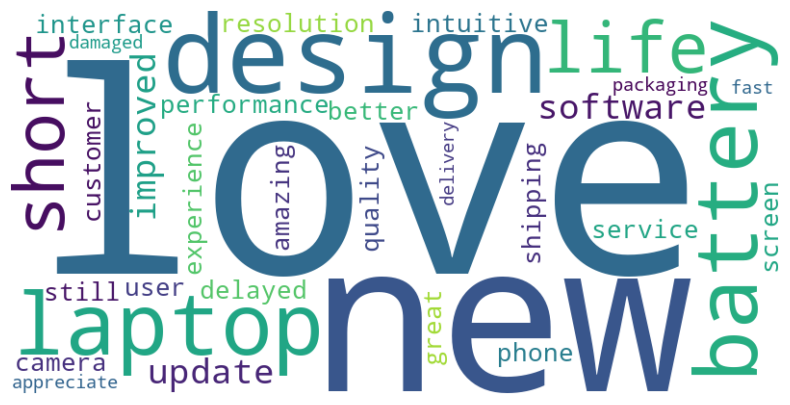

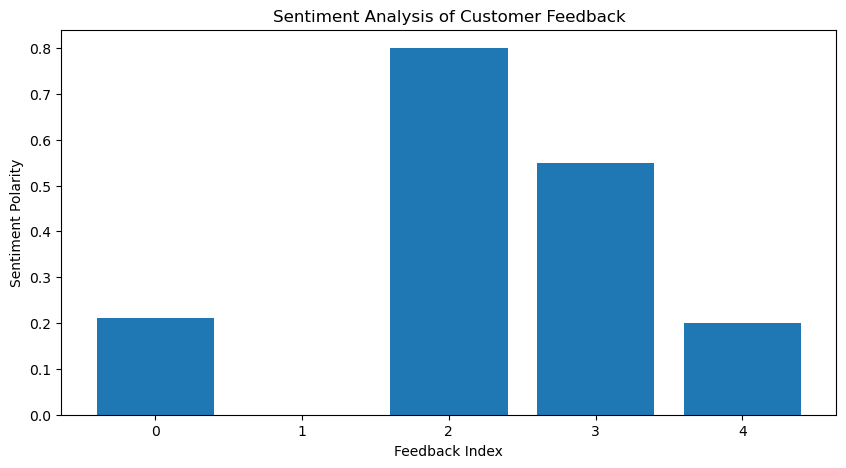

In [9]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Generate word cloud for all feedback
all_feedback = " ".join(preprocessed_feedback)
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(
    all_feedback
)

# Plot word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# Plot sentiments
plt.figure(figsize=(10, 5))
plt.bar(range(len(sentiments)), sentiments)
plt.xlabel("Feedback Index")
plt.ylabel("Sentiment Polarity")
plt.title("Sentiment Analysis of Customer Feedback")
plt.show()